In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from datetime import timedelta
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "font.size": 11
})
pd.set_option("display.max_columns", None)


## 1. Đọc dữ liệu (4 bảng)

In [35]:
df_products = pd.read_csv("../data/products.csv")
df_categories = pd.read_csv("../data/categories.csv")
df_stores = pd.read_csv("../data/stores.csv")
df_reviews = pd.read_csv("../data/reviews.csv")  # đồng bộ bộ dữ liệu; không dùng trực tiếp ở các bước dưới


## 2. Làm sạch cơ bản

In [36]:
df_products = df_products.drop_duplicates(subset="product_id")
df_stores = df_stores.drop_duplicates(subset="store_id")
df_categories = df_categories.drop_duplicates(subset="category_id")

for col in ["price", "original_price", "discount_percent", "sold_count", "rating_avg", "review_count"]:
    if col in df_products.columns:
        df_products[col] = pd.to_numeric(df_products[col], errors="coerce")

for col in ["store_rating", "follower_count"]:
    if col in df_stores.columns:
        df_stores[col] = pd.to_numeric(df_stores[col], errors="coerce")

if "created_at" in df_products.columns:
    df_products["created_at"] = pd.to_datetime(df_products["created_at"], errors="coerce")

# lọc giá trị không hợp lệ
df_products = df_products[
    (df_products["sold_count"].fillna(0) >= 0) &
    (df_products["review_count"].fillna(0) >= 0) &
    (df_products["rating_avg"].fillna(0).between(0, 5)) &
    (df_products["price"].fillna(0) >= 0)
].copy()

df_stores = df_stores[
    (df_stores["store_rating"].fillna(0).between(0, 5)) &
    (df_stores["follower_count"].fillna(0) >= 0)
].copy()


## 3. Ghép bảng → `df_thuong_01`

In [37]:
df_thuong_01 = df_products.merge(
    df_stores[["store_id", "store_name", "store_rating", "follower_count"]],
    on="store_id",
    how="left"
).merge(
    df_categories[["category_id", "category_name", "parent_category"]],
    on="category_id",
    how="left"
)


## 4. Chuẩn bị tập phân tích insight (lọc + biến phụ)

In [38]:
# store_rating > 0, sold_count > 0, rating_avg > 0, follower_count > 0
df_insight = df_thuong_01[
    (df_thuong_01["store_rating"] > 0) &
    (df_thuong_01["sold_count"] > 0) &
    (df_thuong_01["rating_avg"] > 0) &
    (df_thuong_01["follower_count"] > 0)
].copy()

print(f"Số sản phẩm sau lọc (insight): {len(df_insight):,}")

df_insight["log_sold"] = np.log1p(df_insight["sold_count"])
df_insight["log_review"] = np.log1p(df_insight["review_count"])
df_insight["log_follower"] = np.log1p(df_insight["follower_count"])

df_insight["store_rating_group"] = pd.cut(
    df_insight["store_rating"],
    bins=[0, 4.0, 4.5, 4.8, 5.0],
    labels=["≤ 4.0", "4.0–4.5", "4.5–4.8", "4.8–5.0"],
    include_lowest=True
)

df_insight["follower_group"] = pd.qcut(
    df_insight["follower_count"].rank(method="first"),
    q=4,
    labels=["Q1 Ít follower", "Q2", "Q3", "Q4 Nhiều follower"]
)

store_agg = df_insight.groupby(
    ["store_id", "store_name", "store_rating", "follower_count"], as_index=False
).agg(
    total_sold=("sold_count", "sum"),
    total_reviews=("review_count", "sum"),
    avg_product_rating=("rating_avg", "mean"),
    num_products=("product_id", "count")
)

store_agg["log_total_sold"] = np.log1p(store_agg["total_sold"])
store_agg["log_total_reviews"] = np.log1p(store_agg["total_reviews"])
store_agg["log_follower"] = np.log1p(store_agg["follower_count"])

print(f"Số cửa hàng (sau lọc insight): {len(store_agg):,}")


Số sản phẩm sau lọc (insight): 9,395
Số cửa hàng (sau lọc insight): 490


## 5. Mục tiêu: Heatmap tương quan Spearman (uy tín cửa hàng ↔ hiệu suất sản phẩm)

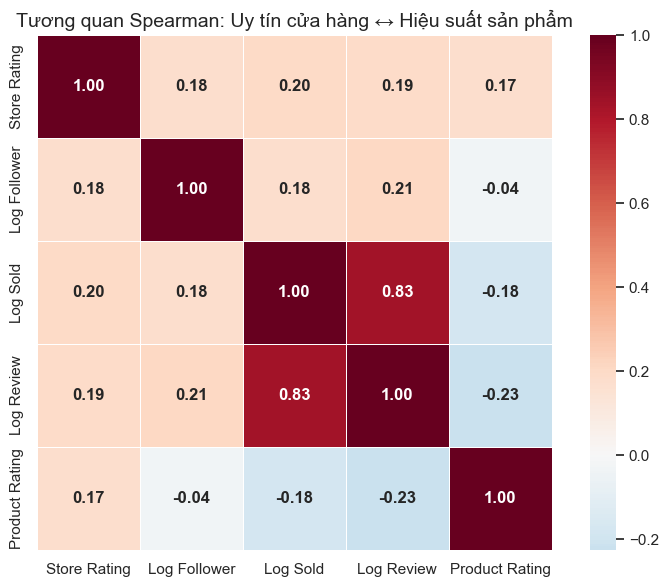

 TƯƠNG QUAN SPEARMAN CHÍNH:
Store Rating → Sold             : r = 0.200, p = 2.06e-85
Store Rating → Review           : r = 0.190, p = 8.23e-77
Store Rating → Product Rating   : r = 0.172, p = 2.03e-63
Follower → Sold                 : r = 0.182, p = 2.01e-70
Follower → Review               : r = 0.209, p = 4.31e-93
Follower → Product Rating       : r = -0.035, p = 6.40e-04


In [39]:
corr_df = df_insight[["store_rating", "log_follower", "log_sold", "log_review", "rating_avg"]].copy()
corr_df.columns = ["Store Rating", "Log Follower", "Log Sold", "Log Review", "Product Rating"]

corr_matrix = corr_df.corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    annot_kws={"fontsize": 12, "fontweight": "bold"}
)
plt.title("Tương quan Spearman: Uy tín cửa hàng ↔ Hiệu suất sản phẩm")
plt.tight_layout()
plt.show()

print(" TƯƠNG QUAN SPEARMAN CHÍNH:")
pairs = [
    ("store_rating", "log_sold", "Store Rating → Sold"),
    ("store_rating", "log_review", "Store Rating → Review"),
    ("store_rating", "rating_avg", "Store Rating → Product Rating"),
    ("log_follower", "log_sold", "Follower → Sold"),
    ("log_follower", "log_review", "Follower → Review"),
    ("log_follower", "rating_avg", "Follower → Product Rating")
]
for x, y, label in pairs:
    sub = df_insight[[x, y]].dropna()
    r, p = spearmanr(sub[x], sub[y])
    print(f"{label:32s}: r = {r:.3f}, p = {p:.2e}")


## 6. Mục tiêu: Scatter mức cửa hàng — follower hay rating phản ánh doanh số rõ hơn?

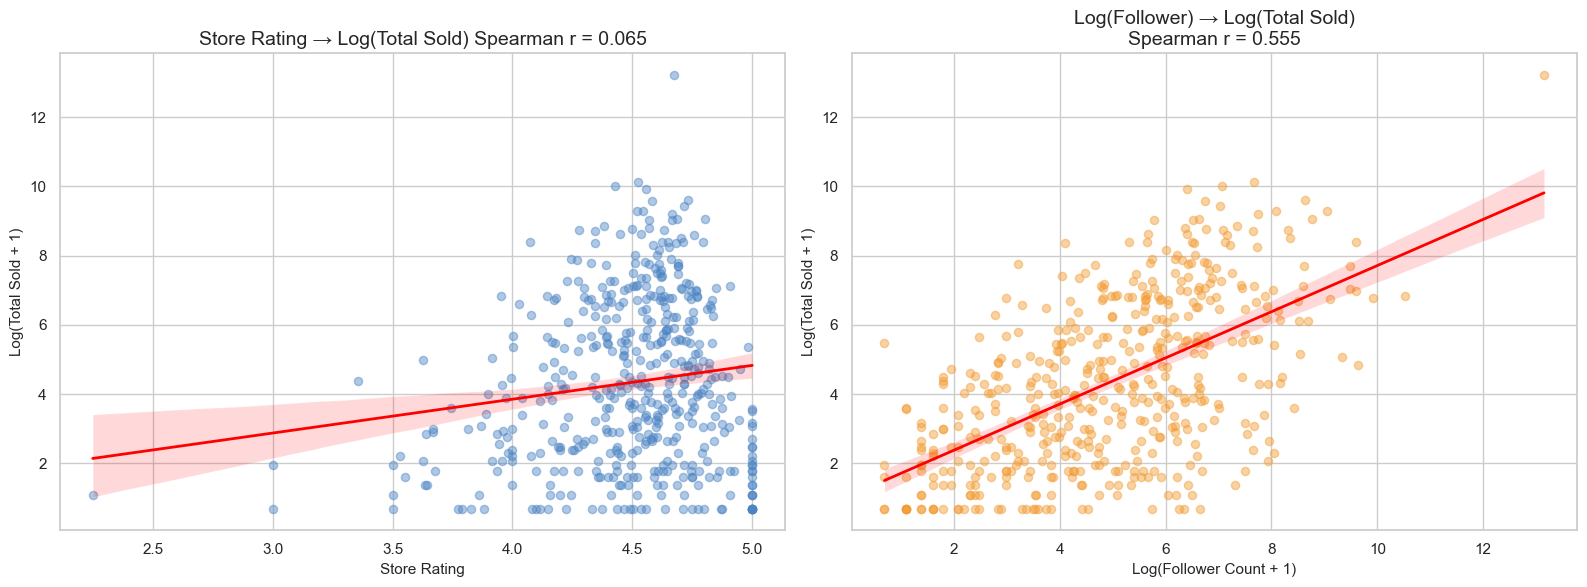

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

r_store_sold, _ = spearmanr(store_agg["store_rating"], store_agg["log_total_sold"])
sns.regplot(
    data=store_agg,
    x="store_rating",
    y="log_total_sold",
    scatter_kws={"alpha": 0.45, "s": 35, "color": "#4C84C4"},
    line_kws={"color": "red", "linewidth": 2},
    ax=axes[0]
)
axes[0].set_title(f"Store Rating → Log(Total Sold) Spearman r = {r_store_sold:.3f}")
axes[0].set_xlabel("Store Rating")
axes[0].set_ylabel("Log(Total Sold + 1)")

r_follow_sold, _ = spearmanr(store_agg["log_follower"], store_agg["log_total_sold"])
sns.regplot(
    data=store_agg,
    x="log_follower",
    y="log_total_sold",
    scatter_kws={"alpha": 0.45, "s": 35, "color": "#F39C34"},
    line_kws={"color": "red", "linewidth": 2},
    ax=axes[1]
)
axes[1].set_title(f"Log(Follower) → Log(Total Sold)\nSpearman r = {r_follow_sold:.3f}")
axes[1].set_xlabel("Log(Follower Count + 1)")
axes[1].set_ylabel("Log(Total Sold + 1)")

plt.tight_layout()
plt.show()


## 7. Mục tiêu: Shop uy tín hơn có đi kèm đánh giá sản phẩm tốt hơn không? (bar theo nhóm store rating)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_39860\3365299978.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


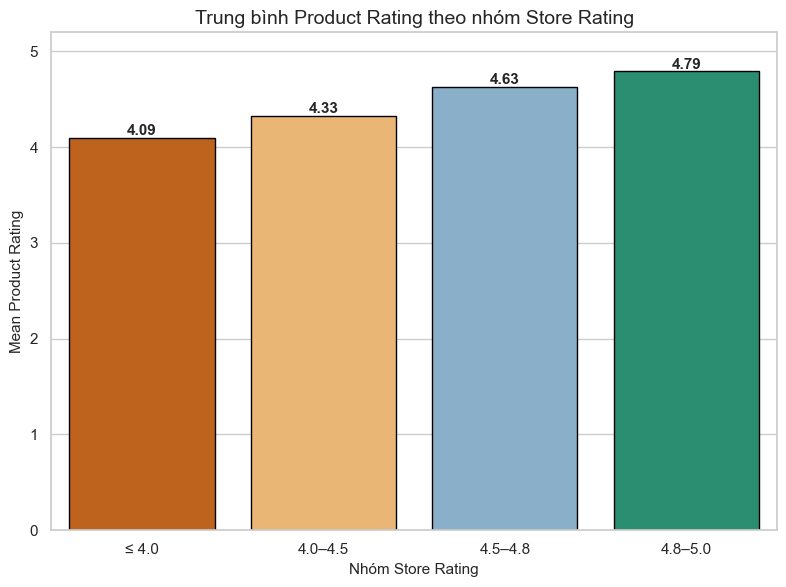

In [41]:
grp_rating = df_insight.groupby("store_rating_group", observed=False).agg(
    mean_product_rating=("rating_avg", "mean"),
    median_sold=("sold_count", "median"),
    median_review=("review_count", "median")
).reset_index()

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=grp_rating,
    x="store_rating_group",
    y="mean_product_rating",
    palette=["#d95f02", "#fdb863", "#80b1d3", "#1b9e77"],
    edgecolor="black"
)

for i, v in enumerate(grp_rating["mean_product_rating"]):
    ax.text(i, v + 0.03, f"{v:.2f}", ha="center", fontweight="bold")

plt.title("Trung bình Product Rating theo nhóm Store Rating")
plt.xlabel("Nhóm Store Rating")
plt.ylabel("Mean Product Rating")
plt.ylim(0, 5.2)
plt.tight_layout()
plt.show()


## 8. Mục tiêu: Follower có phản ánh khả năng bán hàng? (median sold theo nhóm follower)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_39860\227949283.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


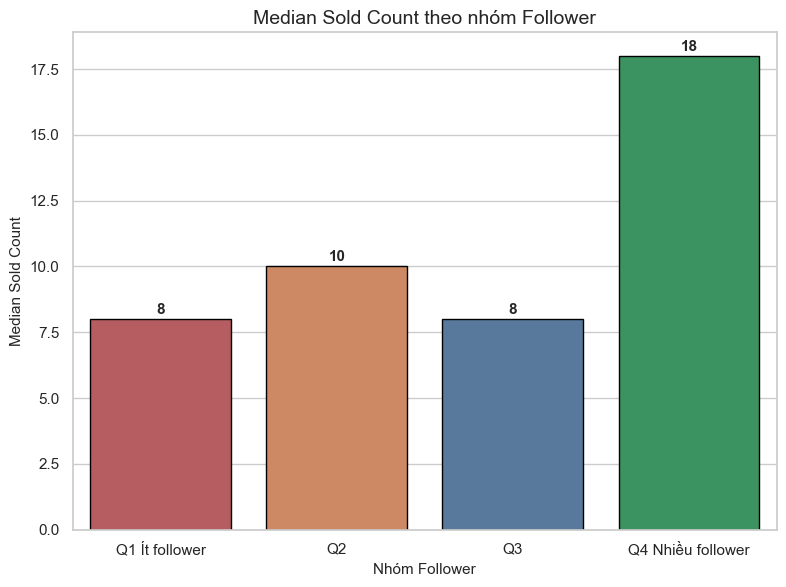

In [42]:
grp_follower = df_insight.groupby("follower_group", observed=False).agg(
    median_sold=("sold_count", "median"),
    median_review=("review_count", "median"),
    mean_product_rating=("rating_avg", "mean")
).reset_index()

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=grp_follower,
    x="follower_group",
    y="median_sold",
    palette=["#c44e52", "#dd8452", "#4c78a8", "#2ca25f"],
    edgecolor="black"
)

for i, v in enumerate(grp_follower["median_sold"]):
    ax.text(i, v + 0.2, f"{v:.0f}", ha="center", fontweight="bold")

plt.title("Median Sold Count theo nhóm Follower")
plt.xlabel("Nhóm Follower")
plt.ylabel("Median Sold Count")
plt.tight_layout()
plt.show()


## 9. Mục tiêu: Vai trò nhà bán hàng có giống nhau ở mọi ngành hàng? (Top 10 × follower)

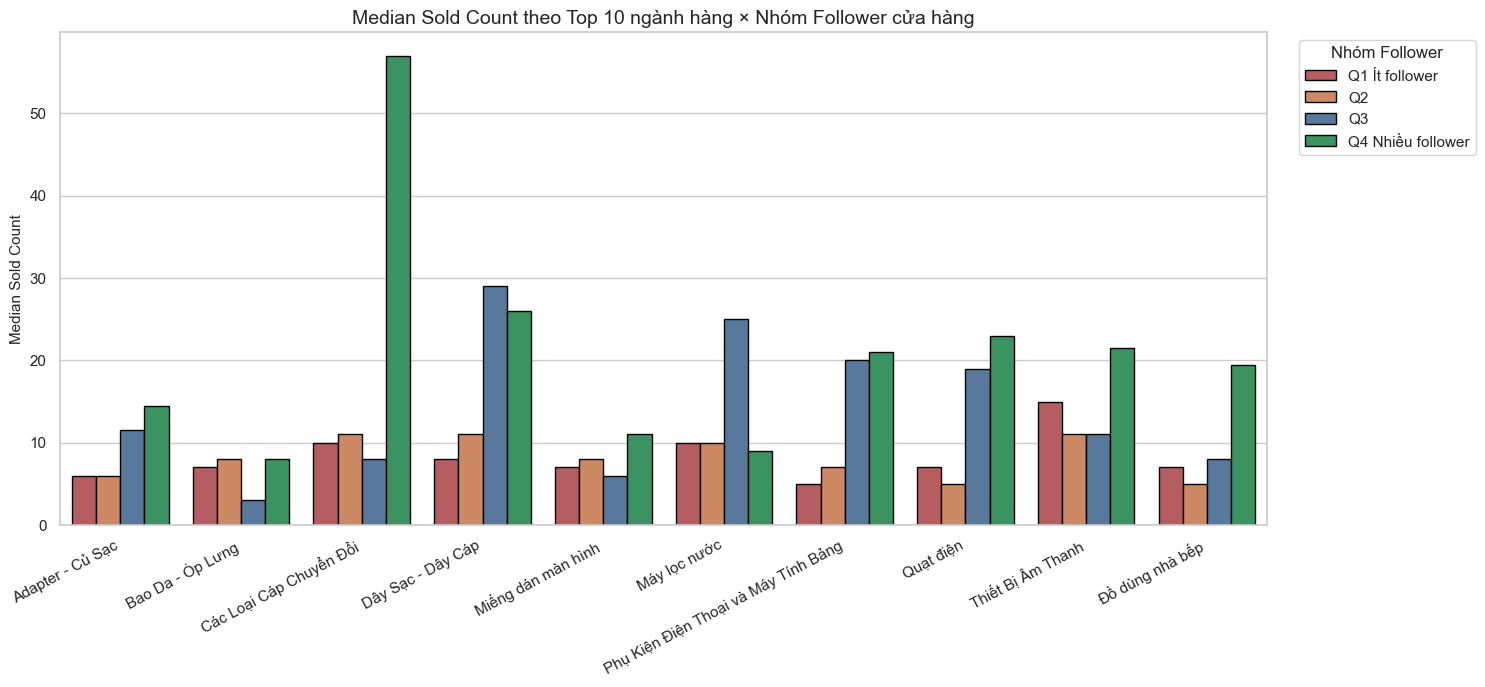

In [43]:
top10_categories = df_insight["parent_category"].value_counts().head(10).index.tolist()
df_top = df_insight[df_insight["parent_category"].isin(top10_categories)].copy()

cat_summary = df_top.groupby(
    ["parent_category", "follower_group"], observed=False
).agg(
    median_sold=("sold_count", "median")
).reset_index()

plt.figure(figsize=(15, 7))
sns.barplot(
    data=cat_summary,
    x="parent_category",
    y="median_sold",
    hue="follower_group",
    palette=["#c44e52", "#dd8452", "#4c78a8", "#2ca25f"],
    edgecolor="black"
)
plt.title("Median Sold Count theo Top 10 ngành hàng × Nhóm Follower cửa hàng")
plt.xlabel("")
plt.ylabel("Median Sold Count")
plt.xticks(rotation=28, ha="right")
plt.legend(title="Nhóm Follower", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 10. Tóm tắt số liệu phục vụ insight

In [46]:
print(" " + "="*70)
print("TÓM TẮT PHỤC VỤ VIẾT INSIGHT")
print("="*70)

print("1. Theo nhóm Store Rating:")
print(grp_rating)

print("\n2. Theo nhóm Follower:")
print(grp_follower)

print("3. Tương quan mức cửa hàng:")
print(f"Store Rating → Log(Total Sold): r = {r_store_sold:.3f}")
print(f"Log(Follower) → Log(Total Sold): r = {r_follow_sold:.3f}")

if len(grp_follower) == 4:
    q1 = grp_follower.iloc[0]["median_sold"]
    q4 = grp_follower.iloc[3]["median_sold"]
    ratio = q4 / q1 if q1 > 0 else np.nan
    print(f" 4. So sánh nhóm follower:")
    print(f"Median sold nhóm Q1 = {q1:.0f}")
    print(f"Median sold nhóm Q4 = {q4:.0f}")
    print(f"Q4 cao gấp khoảng {ratio:.2f} lần Q1")


TÓM TẮT PHỤC VỤ VIẾT INSIGHT
1. Theo nhóm Store Rating:
  store_rating_group  mean_product_rating  median_sold  median_review
0              ≤ 4.0             4.094737          6.0            1.0
1            4.0–4.5             4.327216          7.0            1.0
2            4.5–4.8             4.625492         14.0            2.0
3            4.8–5.0             4.791925          7.0            2.0

2. Theo nhóm Follower:
      follower_group  median_sold  median_review  mean_product_rating
0     Q1 Ít follower          8.0            2.0             4.520732
1                 Q2         10.0            2.0             4.526948
2                 Q3          8.0            2.0             4.404557
3  Q4 Nhiều follower         18.0            3.0             4.589740
3. Tương quan mức cửa hàng:
Store Rating → Log(Total Sold): r = 0.065
Log(Follower) → Log(Total Sold): r = 0.555
 4. So sánh nhóm follower:
Median sold nhóm Q1 = 8
Median sold nhóm Q4 = 18
Q4 cao gấp khoảng 2.25 lần Q1


---
## Phân tích khuyến mãi (90 ngày): tham số

In [47]:
DAYS_BACK = 90
MIN_CELL_N = 100  # ngưỡng n tối thiểu cho từng ô (Discount × Group)

DISCOUNT_ORDER = ["Thấp (0-10%)", "Trung bình (11-30%)", "Cao (>30%)"]
FOLLOWER_ORDER = ["Follower thấp", "Follower trung bình", "Follower cao"]
RATING_ORDER = ["Rating thấp (≤4.0)", "Rating trung bình (4.0-4.5)", "Rating cao (>4.5)"]

plt.rcParams.update({"figure.figsize": (12, 6), "axes.titlesize": 13})


## 11. Mục tiêu: Chuẩn bị tập phân tích giảm giá × follower × rating (từ `df_thuong_01`)

In [50]:
df_discount = df_thuong_01.copy()

if "created_at" in df_discount.columns and df_discount["created_at"].notna().sum() > 0:
    cutoff = df_discount["created_at"].max() - timedelta(days=DAYS_BACK)
    df_discount = df_discount[df_discount["created_at"] >= cutoff].copy()
    print(f"✅ Lọc {DAYS_BACK} ngày gần nhất từ {cutoff.date()} → {len(df_discount):,} sản phẩm")
else:
    print("⚠️ Không có created_at hợp lệ → dùng toàn bộ dữ liệu")

df_discount = df_discount[
    (df_discount["sold_count"] > 0) &
    (df_discount["discount_percent"].notna()) & (df_discount["discount_percent"] >= 0) &
    (df_discount["store_rating"].notna()) & (df_discount["store_rating"] > 0) &
    (df_discount["follower_count"].notna()) & (df_discount["follower_count"] > 0)
].copy()

df_discount["log_sold"] = np.log1p(df_discount["sold_count"])
df_discount["discount_percent"] = df_discount["discount_percent"].clip(0, 100)

df_discount["discount_bin"] = pd.cut(
    df_discount["discount_percent"],
    bins=[-1, 10, 30, 100],
    labels=DISCOUNT_ORDER
)

df_discount["follower_group"] = pd.qcut(
    df_discount["follower_count"].rank(method="first"),
    q=3,
    labels=FOLLOWER_ORDER
)

df_discount["rating_group"] = pd.cut(
    df_discount["store_rating"],
    bins=[0, 4.0, 4.5, 5.0],
    labels=RATING_ORDER,
    include_lowest=True
)

df_discount = df_discount[
    df_discount["discount_bin"].notna() & df_discount["follower_group"].notna() & df_discount["rating_group"].notna()
].copy()
print(f"✅ Sau lọc hợp lệ bin/group: {len(df_discount):,} sản phẩm")

df_discount["discount_bin"] = pd.Categorical(df_discount["discount_bin"], categories=DISCOUNT_ORDER, ordered=True)
df_discount["follower_group"] = pd.Categorical(df_discount["follower_group"], categories=FOLLOWER_ORDER, ordered=True)
df_discount["rating_group"] = pd.Categorical(df_discount["rating_group"], categories=RATING_ORDER, ordered=True)


⚠️ Không có created_at hợp lệ → dùng toàn bộ dữ liệu
✅ Sau lọc hợp lệ bin/group: 18,555 sản phẩm


## 12. Mục tiêu: Bar — Median Log(Sold) theo mức khuyến mãi × nhóm follower (+ n)

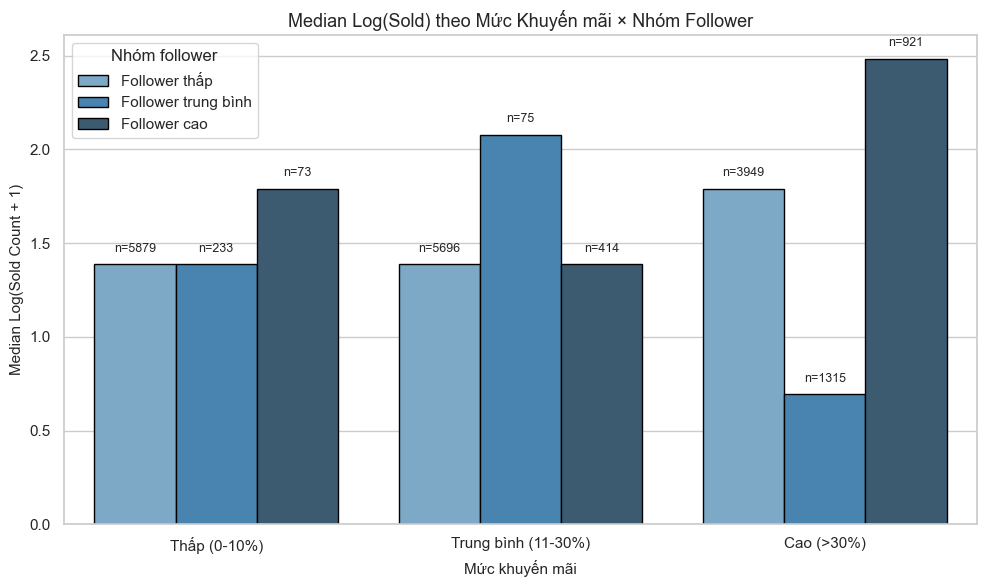

In [51]:
def annotate_n_from_lookup(ax, x_order, hue_order, n_lookup, y_pad=0.02, fontsize=9):
    combos = [(x, h) for x in x_order for h in hue_order]
    patches = [p for p in ax.patches if p.get_width() > 0]
    m = min(len(patches), len(combos))
    y_max = max([p.get_height() for p in patches[:m]] + [0])

    for i in range(m):
        x, h = combos[i]
        p = patches[i]
        n = int(n_lookup.get((x, h), 0))
        ax.text(
            p.get_x() + p.get_width() / 2,
            p.get_height() + (y_max * y_pad),
            f"n={n}",
            ha="center", va="bottom",
            fontsize=fontsize
        )


cell_f = (df_discount.groupby(["discount_bin", "follower_group"], observed=False)
            .agg(median_log_sold=("log_sold", "median"),
                 n=("log_sold", "size"))
            .reset_index())

n_lookup_f = {(r["discount_bin"], r["follower_group"]): r["n"] for _, r in cell_f.iterrows()}

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=cell_f,
    x="discount_bin", y="median_log_sold",
    hue="follower_group",
    order=DISCOUNT_ORDER, hue_order=FOLLOWER_ORDER,
    palette="Blues_d", edgecolor="black",
    errorbar=None
)
plt.title("Median Log(Sold) theo Mức Khuyến mãi × Nhóm Follower")
plt.xlabel("Mức khuyến mãi")
plt.ylabel("Median Log(Sold Count + 1)")
plt.legend(title="Nhóm follower", loc="upper left")
annotate_n_from_lookup(ax, DISCOUNT_ORDER, FOLLOWER_ORDER, n_lookup_f)
plt.tight_layout()
plt.show()


## 13. Mục tiêu: Heatmap median Log(Sold) & heatmap n (mask ô nhỏ) + uplift định lượng

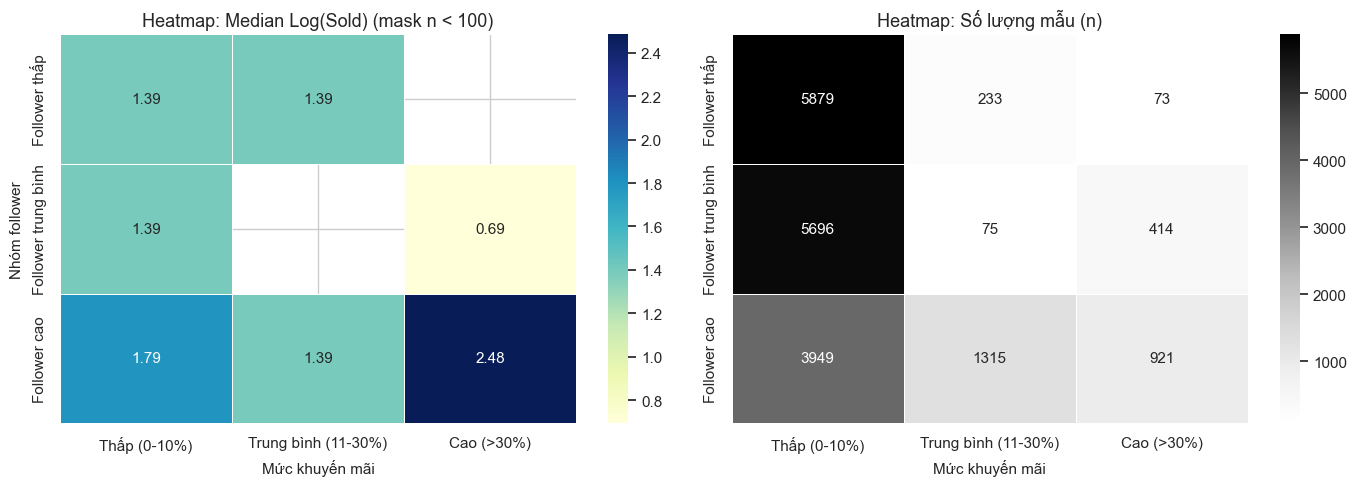

=== Uplift khi GIẢM GIÁ CAO (>30%) so với THẤP (0-10%) (chỉ nhóm đủ n) ===


,delta_log,approx_multiplier_(sold+1)
follower_group,,
Follower thấp,NaN,NaN
Follower trung bình,-0.693147,0.5
Follower cao,0.693147,2.0


In [53]:
pivot_median = cell_f.pivot(index="follower_group", columns="discount_bin", values="median_log_sold").reindex(FOLLOWER_ORDER)
pivot_n = cell_f.pivot(index="follower_group", columns="discount_bin", values="n").reindex(FOLLOWER_ORDER)

mask_small = pivot_n < MIN_CELL_N

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    pivot_median, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5,
    mask=mask_small, ax=axes[0]
)
axes[0].set_title(f"Heatmap: Median Log(Sold) (mask n < {MIN_CELL_N})")
axes[0].set_xlabel("Mức khuyến mãi")
axes[0].set_ylabel("Nhóm follower")

sns.heatmap(
    pivot_n, annot=True, fmt=".0f", cmap="Greys", linewidths=0.5, ax=axes[1]
)
axes[1].set_title("Heatmap: Số lượng mẫu (n)")
axes[1].set_xlabel("Mức khuyến mãi")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

uplift = (pivot_median["Cao (>30%)"] - pivot_median["Thấp (0-10%)"]).rename("delta_log")
ok = (~mask_small["Cao (>30%)"]) & (~mask_small["Thấp (0-10%)"])

uplift_df = pd.DataFrame({
    "delta_log": uplift.where(ok),
    "approx_multiplier_(sold+1)": np.exp(uplift.where(ok))
})
print("=== Uplift khi GIẢM GIÁ CAO (>30%) so với THẤP (0-10%) (chỉ nhóm đủ n) ===")
display(uplift_df)


## 14. Mục tiêu: Bar — Median Log(Sold) theo mức khuyến mãi × nhóm store rating (+ n)

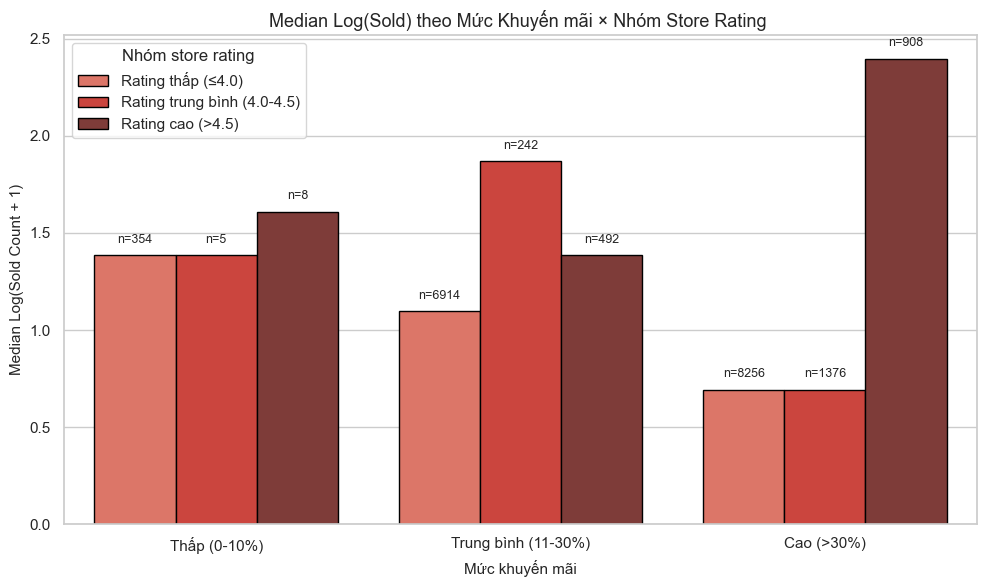

In [54]:
cell_r = (df_discount.groupby(["discount_bin", "rating_group"], observed=False)
            .agg(median_log_sold=("log_sold", "median"),
                 n=("log_sold", "size"))
            .reset_index())

n_lookup_r = {(r["discount_bin"], r["rating_group"]): r["n"] for _, r in cell_r.iterrows()}

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=cell_r,
    x="discount_bin", y="median_log_sold",
    hue="rating_group",
    order=DISCOUNT_ORDER, hue_order=RATING_ORDER,
    palette="Reds_d", edgecolor="black",
    errorbar=None
)
plt.title("Median Log(Sold) theo Mức Khuyến mãi × Nhóm Store Rating ")
plt.xlabel("Mức khuyến mãi")
plt.ylabel("Median Log(Sold Count + 1)")
plt.legend(title="Nhóm store rating", loc="upper left")
annotate_n_from_lookup(ax, DISCOUNT_ORDER, RATING_ORDER, n_lookup_r)
plt.tight_layout()
plt.show()
